# Session 9: Synthetic Data Generation and RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow, and use it to evaluate and iterate on a RAG pipeline with LangSmith!

**Learning Objectives:**
- Understand Ragas' knowledge graph-based synthetic data generation workflow
- Generate synthetic test sets with different query synthesizer types
- Load synthetic data into LangSmith for evaluation
- Evaluate a RAG chain using LangSmith evaluators
- Iterate on RAG pipeline parameters and measure the impact

## Table of Contents:

- **Breakout Room #1:** Synthetic Data Generation with Ragas
  - Task 1: Dependencies and API Keys
  - Task 2: Data Preparation and Knowledge Graph Construction
  - Task 3: Generating Synthetic Test Data
  - Question #1 & Question #2
  - 🏗️ Activity #1: Custom Query Distribution

- **Breakout Room #2:** RAG Evaluation with LangSmith
  - Task 4: LangSmith Dataset Setup
  - Task 5: Building a Basic RAG Chain
  - Task 6: Evaluating with LangSmith
  - Task 7: Modifying the Pipeline and Re-Evaluating
  - Question #3 & Question #4
  - 🏗️ Activity #2: Analyze Evaluation Results

---
# 🤝 Breakout Room #1
## Synthetic Data Generation with Ragas

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/risheeksomu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/risheeksomu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [2]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

We'll also want to set a project name to make things easier for ourselves.

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [4]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data using two complementary guides — a Health & Wellness Guide covering exercise, nutrition, sleep, and stress management, and a Mental Health & Psychology Handbook covering mental health conditions, therapeutic approaches, resilience, and daily mental health practices. The topical overlap between documents helps RAGAS build rich cross-document relationships in the knowledge graph.

Next, let's load our data into a familiar LangChain format using the `TextLoader`.

In [27]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader

loader = DirectoryLoader("data/", glob="*.txt", loader_cls=TextLoader)
docs = loader.load()
print(f"Loaded {len(docs)} documents: {[d.metadata['source'] for d in docs]}")

Loaded 2 documents: ['data/MentalHealthGuide.txt', 'data/HealthWellnessGuide.txt']


### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [28]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [29]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [30]:
from ragas.testset.graph import Node, NodeType

for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 2, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [31]:
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/8 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/18 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 10, relationships: 21)

We can save and load our knowledge graphs as follows.

In [32]:
kg.save("usecase_data_kg.json")
usecase_data_kg = KnowledgeGraph.load("usecase_data_kg.json")
usecase_data_kg

KnowledgeGraph(nodes: 10, relationships: 21)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [33]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=usecase_data_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [34]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

## ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.

##### Answer:

SingleHopSpecificQuerySynthesizer: This generates straightforward questions that can be answered by retrieving information from a single chunk or source in the knowledge graph. Only one "hop" is needed, meaning the system looks at one node, finds the relevant fact, and produces an answer. These are your baseline factual questions like "What does Stage 2 of sleep involve?"

MultiHopAbstractQuerySynthesizer: This generates questions that require pulling from multiple connected nodes in the knowledge graph, but asks them at a high level. It finds nodes that share similar themes or relationships and creates a broad, conceptual question that spans across them. The answer requires synthesizing ideas from multiple sources, but the question itself is about patterns and big picture connections rather than specific details. For example, "How does sleep hygiene influence sleep quality?" draws from multiple chunks but asks about a general relationship, not a particular section of the document.

MultiHopSpecificQuerySynthesizer: This also generates questions requiring multiple chunks, but unlike the abstract version, it targets precise, concrete details across those sources. It identifies overlap between specific sections and creates questions that force the system to locate and combine particular facts from different parts of the knowledge graph. For example, "How do Chapters 9 and 21 together inform strategies for managing sleep disorders?" requires pulling specific information from two distinct sections and synthesizing a precise answer from both.

Finally, we can use our `TestSetGenerator` to generate our testset!

In [36]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,What is the Psychology Handbook?,[The Mental Health and Psychology Handbook A P...,The Mental Health and Psychology Handbook is a...,single_hop_specifc_query_synthesizer
1,What is the University of Massachusetts Medica...,[PART 2: THERAPEUTIC APPROACHES Chapter 4: Cog...,The University of Massachusetts Medical Center...,single_hop_specifc_query_synthesizer
2,What is Omega-3 in the context of mental health?,[Write letters to or from your future self Jou...,"Omega-3 fatty acids are found in fatty fish, w...",single_hop_specifc_query_synthesizer
3,What is the purpose of including an appendix i...,[social interactions How to set and maintain b...,The appendix provides additional mental health...,single_hop_specifc_query_synthesizer
4,What is a Personal Wellness Guide?,[The Personal Wellness Guide A Comprehensive R...,The Personal Wellness Guide is a comprehensive...,single_hop_specifc_query_synthesizer
5,How can adopting healthy digital habits suppor...,[<1-hop>\n\nWrite letters to or from your futu...,The context highlights that managing digital h...,multi_hop_abstract_query_synthesizer
6,How can mindfulness and meditation practices h...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,"Mindfulness and meditation practices, such as ...",multi_hop_abstract_query_synthesizer
7,How can exercises for common problems like low...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,The context provides exercises such as gentle ...,multi_hop_abstract_query_synthesizer
8,How can CBT-I help improve sleep and mental he...,[<1-hop>\n\nWrite letters to or from your futu...,"CBT-I, or Cognitive Behavioral Therapy for Ins...",multi_hop_specific_query_synthesizer
9,Hwo can I use chapter 7 and 13 to imprve my sl...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,"Using the information from Chapter 7, which ex...",multi_hop_specific_query_synthesizer


### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [37]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/2 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/2 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/8 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/18 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [38]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,What insights does the Psychology Handbook pro...,[The Mental Health and Psychology Handbook A P...,The Mental Health and Psychology Handbook emph...,single_hop_specifc_query_synthesizer
1,Wha is the University of Massachusetts Medical...,[PART 2: THERAPEUTIC APPROACHES Chapter 4: Cog...,The University of Massachusetts Medical Center...,single_hop_specifc_query_synthesizer
2,What role does oxytocin play in mental health ...,[Write letters to or from your future self Jou...,The provided context mentions that oxytocin ac...,single_hop_specifc_query_synthesizer
3,Who are Licensed Clinical Social Workers?,[social interactions How to set and maintain b...,Licensed Clinical Social Workers are mental he...,single_hop_specifc_query_synthesizer
4,How do supporting immune function throuh lifes...,[<1-hop>\n\nPART 5: BUILDING HEALTHY HABITS Ch...,Supporting immune function through lifestyle a...,multi_hop_abstract_query_synthesizer
5,like if someone wants to build a workout routi...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,To improve both your workout routine and sleep...,multi_hop_abstract_query_synthesizer
6,how support immune function through lifestyle ...,[<1-hop>\n\nPART 5: BUILDING HEALTHY HABITS Ch...,support immune function through lifestyle and ...,multi_hop_abstract_query_synthesizer
7,How do key nutrients like Omega-3 and Vitamin ...,[<1-hop>\n\nPART 2: THERAPEUTIC APPROACHES Cha...,The context highlights that key nutrients such...,multi_hop_abstract_query_synthesizer
8,How do Chapters 9 and 16 together inform strat...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,Chapter 9 discusses understanding and managing...,multi_hop_specific_query_synthesizer
9,How does chapter 3 about building habits conne...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,Chapter 3 explains that habits are behaviors t...,multi_hop_specific_query_synthesizer


## ❓ Question #2:

Ragas offers both an "unrolled" (manual) approach and an "abstracted" (automatic) approach to synthetic data generation. What are the trade-offs between these two approaches? When would you choose one over the other?

##### Answer:
The unrolled (manual) approach gives you full control over every step of the synthetic data generation pipeline. You create an empty KnowledgeGraph yourself, manually add document nodes, choose and apply transforms explicitly, and define your own query distribution with custom synthesizer weights. This means you can inspect the KG at every stage, checking the node count, relationships, and entity details after each transformation to verify things look right. A major practical benefit is that you can save the KG to disk and regenerate different test sets from the same graph without re-running the expensive transform step, which saves both time and API costs.

The abstracted approach wraps all of this into a single generate_with_langchain_docs() call. It handles building the KG, applying default transforms, and generating questions all at once. You never see the intermediate KG, you can't customize the transforms, and it uses the default query distribution. The tradeoff is speed and simplicity: you can go from raw documents to a complete test set in about 3 lines of code.

You would choose the unrolled approach when building production quality evaluation sets where you need to customize the query distribution (for example, weighting 80% multi-hop questions because you know your system struggles there), when you want to debug why certain questions are being generated, or when you plan to iterate on the test set multiple times from the same underlying knowledge graph. The abstracted approach is better for quick prototyping and early exploration when you just need a directional sense of how your pipeline is performing and the defaults are good enough.

This mirrors the same tradeoff seen in LangGraph between create_react_agent (abstracted, quick, opinionated defaults) and building a custom StateGraph from scratch (full control, more code, but customizable at every decision point).

---
## 🏗️ Activity #1: Custom Query Distribution

Modify the `query_distribution` to experiment with different ratios of query types.

### Requirements:
1. Create a custom query distribution with different weights than the default
2. Generate a new test set using your custom distribution
3. Compare the types of questions generated with the default distribution
4. Explain why you chose the weights you did

In [39]:

# Define a custom query distribution with different weights
custom_query_distribution = [
    (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.2),
    (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.4),
    (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.4),
]

# Generate a new test set and compare with the default
custom_testset = generator.generate(testset_size=10, query_distribution = custom_query_distribution)
custom_testset.to_pandas()

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,WHO mental health?,[The Mental Health and Psychology Handbook A P...,"According to the context, the World Health Org...",single_hop_specifc_query_synthesizer
1,Hwo can CBT help with mental health issues lik...,[PART 2: THERAPEUTIC APPROACHES Chapter 4: Cog...,Cognitive Behavioral Therapy (CBT) is one of t...,single_hop_specifc_query_synthesizer
2,How can behavioral techniques and mindfulness ...,[<1-hop>\n\nPART 2: THERAPEUTIC APPROACHES Cha...,Integrating behavioral techniques and mindfuln...,multi_hop_abstract_query_synthesizer
3,"How does poor sleep, which is often linked to ...",[<1-hop>\n\nWrite letters to or from your futu...,"Poor sleep can impair emotional regulation, in...",multi_hop_abstract_query_synthesizer
4,How can self-compassion help recognize signs n...,[<1-hop>\n\nsocial interactions How to set and...,Self-compassion can support individuals in rec...,multi_hop_abstract_query_synthesizer
5,How does the impact of mental health on physic...,[<1-hop>\n\nThe Mental Health and Psychology H...,The Mental Health and Psychology Handbook emph...,multi_hop_abstract_query_synthesizer
6,How can understanding the science of sleep and...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,Understanding the science of sleep detailed in...,multi_hop_specific_query_synthesizer
7,In chapter 2 and chapter 21 how build healthy ...,[<1-hop>\n\nThe Personal Wellness Guide A Comp...,Chapter 2 explains that building healthy habit...,multi_hop_specific_query_synthesizer
8,How do Chapters 2 and 7 together inform strate...,[<1-hop>\n\nPART 3: SLEEP AND RECOVERY Chapter...,Chapter 7 explains the importance of sleep for...,multi_hop_specific_query_synthesizer
9,How can CBT and CBT-I help improve mental heal...,[<1-hop>\n\nWrite letters to or from your futu...,Cognitive Behavioral Therapy (CBT) helps impro...,multi_hop_specific_query_synthesizer


I chose to shift the distribution heavily toward multi-hop questions (80% combined) and reduce single-hop to just 20%. My reasoning is based on what we observed from the default distribution results.

The default distribution (0.5/0.25/0.25) showed that the RAG chain handled most single-hop questions well. These are straightforward retrieval tasks where the system finds one relevant chunk and answers from it. Since we already have confidence the system works at this level, generating more single-hop questions would just confirm what we already know without revealing new weaknesses.
Multi-hop questions are where RAG systems typically struggle because they require the retriever to find multiple relevant chunks and the LLM to synthesize information across them. By weighting 40% toward abstract multi-hop and 40% toward specific multi-hop, I'm deliberately creating an evaluation set that pressures the hardest parts of the pipeline: cross-document retrieval and multi-source synthesis.

The even 40/40 split between abstract and specific multi-hop is intentional. Abstract questions test whether the system can identify broad thematic connections across documents (like the relationship between physical wellness and mental health practices). Specific multi-hop questions test whether the system can locate and combine precise details from different sections (like comparing specific techniques from Chapter 7 and Chapter 17). These are two different failure modes and I want visibility into both.

Compared to the default distribution, I would expect this custom test set to produce lower overall scores since we're removing the "easy wins" from single-hop questions and replacing them with harder questions. But the value is in understanding exactly where and how the system fails on complex queries, which tells us what to improve. The generated test set confirmed this approach, producing 8 multi-hop questions out of 10 that target cross-document reasoning about topics like combining CBT techniques, vitamin roles across nutrition and health, and the connection between social connection and mental health boundaries.

We'll need to provide our LangSmith API key, and set tracing to "true".

---
# 🤝 Breakout Room #2
## RAG Evaluation with LangSmith

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [41]:
from langsmith import Client
import uuid

client = Client()

dataset_name = f"Use Case Synthetic Data - AIE9 - {uuid.uuid4()}"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Synthetic Data for Use Cases"
)

We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [42]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [43]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [44]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [45]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [46]:
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="use_case_rag"
)

In [47]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [48]:
from langchain_core.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

As is usual: We'll be using `gpt-4.1-mini` for our RAG!

In [49]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [50]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [51]:
rag_chain.invoke({"question" : "What are some recommended exercises for lower back pain?"})

'Recommended exercises for lower back pain include:\n\n- Cat-Cow Stretch: Start on hands and knees, alternate between arching your back up (cat) and letting it sag down (cow). Do 10-15 repetitions.  \n- Bird Dog: From hands and knees, extend opposite arm and leg while keeping your core engaged. Hold for 5 seconds, then switch sides. Do 10 repetitions per side.  \n- Partial Crunches: Lie on your back with knees bent, cross arms over chest, tighten stomach muscles and raise shoulders off floor. Hold briefly, then lower. Do 8-12 repetitions.  \n- Knee-to-Chest Stretch: Lie on your back, pull one knee toward your chest while keeping the other foot flat. Hold for 15-30 seconds, then switch legs.  \n- Pelvic Tilts: Lie on your back with knees bent, flatten your back against the floor by tightening abs and tilting pelvis up slightly. Hold for 10 seconds, repeat 8-12 times.'

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [52]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [53]:
from openevals.llm import create_llm_as_judge
from langsmith.evaluation import evaluate

# 1. QA Correctness (replaces LangChainStringEvaluator("qa"))
qa_evaluator = create_llm_as_judge(
    prompt="You are evaluating a QA system. Given the input, assess whether the prediction is correct.\n\nInput: {inputs}\nPrediction: {outputs}\nReference answer: {reference_outputs}\n\nIs the prediction correct? Return 1 if correct, 0 if incorrect.",
    feedback_key="qa",
    model="openai:gpt-4o" ,  # pass your LangChain chat model directly
)

# 2. Labeled Helpfulness (replaces LangChainStringEvaluator("labeled_criteria"))
labeled_helpfulness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "helpfulness: Is this submission helpful to the user, "
        "taking into account the correct reference answer?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n"
        "Reference answer: {reference_outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="helpfulness",
    model="openai:gpt-4o" ,
)

# 3. Dopeness (replaces LangChainStringEvaluator("criteria"))
dopeness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "dopeness: Is this response dope, lit, cool, or is it just a generic response?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="dopeness",
    model="openai:gpt-4o" ,
)

> **Describe what each evaluator is evaluating:**
>
> - `qa_evaluator`:
> - `labeled_helpfulness_evaluator`:
> - `dopeness_evaluator`:

## LangSmith Evaluation

In [54]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'passionate-milk-68' at:
https://smith.langchain.com/o/d3190a22-14fd-4e71-b058-10535672d951/datasets/6119ded4-4400-418f-8301-be9993a63f8c/compare?selectedSessions=84013fc3-8c3b-4dee-9d60-0b78bd70bf91




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,How can CBT and CBT-I be combined to improve m...,"Based on the context, CBT (Cognitive Behaviora...",None,Combining Cognitive Behavioral Therapy (CBT) a...,True,True,True,3.425087,14784629-2216-4a42-93c7-d3d97dc529be,019c6883-c17a-7fd1-913f-80cbc7e1274b
1,How can understanding the sleep cycles and sle...,I don't know.,None,Understanding the sleep cycles and sleep hygie...,False,False,False,0.883632,45e98fef-fabd-4129-8ece-a70e18f6d328,019c6883-f40b-77a2-8a0a-5f4153d088a7
2,How does chapter 3 about building habits conne...,I don't know.,None,Chapter 3 explains that habits are behaviors t...,False,False,False,0.711991,16a3e298-ac6b-41c6-9b9f-06013c2261a2,019c6884-159f-7db1-9da3-43f130303ec5
3,How do Chapters 9 and 16 together inform strat...,I don't know.,None,Chapter 9 discusses understanding and managing...,False,False,False,1.032232,b72d600a-5db0-444f-970b-661c0813e1d5,019c6884-3cab-7172-993a-d921351d592a
4,How do key nutrients like Omega-3 and Vitamin ...,Key nutrients like Omega-3 fatty acids and Vit...,None,The context highlights that key nutrients such...,True,True,True,2.871582,dbefb091-72af-4c95-8413-f3393a4f510f,019c6884-647c-7e23-954a-ab55e04e0ae9
5,how support immune function through lifestyle ...,Supporting immune function through lifestyle a...,None,support immune function through lifestyle and ...,True,True,True,5.558973,ee1f7575-f2e4-4a01-9499-d9829cd56f7a,019c6884-9527-7922-8317-b12e8c1301a7
6,like if someone wants to build a workout routi...,To build a workout routine that improves over ...,None,To improve both your workout routine and sleep...,True,True,True,4.586011,74b8a26c-f9e2-4fb5-b590-040a79a7c0a8,019c6884-dc1b-7dd1-afd1-67dc6a144fa7
7,How do supporting immune function throuh lifes...,The context does not explicitly explain how su...,None,Supporting immune function through lifestyle a...,False,False,False,1.026833,f44908d4-fc4e-4cd2-b7c7-fd0937861775,019c6885-25b6-7401-b648-22e895560582
8,Who are Licensed Clinical Social Workers?,Licensed Clinical Social Workers are mental he...,None,Licensed Clinical Social Workers are mental he...,True,True,False,1.475696,e3de3329-e600-4900-a64c-1bf2aad57bce,019c6885-49d6-7ea2-aed9-4cdb8f0a7a83
9,What role does oxytocin play in mental health ...,Oxytocin is activated and released through soc...,None,The provided context mentions that oxytocin ac...,True,False,False,0.990118,d994ad91-8ebc-4759-bb75-5441f61a7f1b,019c6885-6490-7243-aa83-d10a5b76745a


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [55]:
DOPENESS_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Make your answer rad, ensure high levels of dopeness. Do not be generic, or give generic responses.

Context: {context}
Question: {question}
"""

dopeness_rag_prompt = ChatPromptTemplate.from_template(DOPENESS_RAG_PROMPT)

In [56]:
rag_documents = docs

In [57]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

## ❓ Question #3:

Why would modifying our chunk size modify the performance of our application?

##### Answer:
With 500 character chunks, each chunk holds roughly 2 to 3 sentences. For multi-hop questions that need information spanning a full section or multiple sections, the relevant content gets split across several tiny chunks. The retriever may only grab some of them, missing key pieces needed to form a complete answer. This is exactly why the baseline chain answered "I don't know" on several multi-hop questions. Doubling to 1000 characters means each chunk carries more complete context, so the retriever is more likely to pull chunks that contain enough information to answer complex questions. The tradeoff is that larger chunks also contain more irrelevant text mixed in with the relevant parts, but for these documents the benefit of having more complete context available outweighs that noise cost.

In [58]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

## ❓ Question #4:

Why would modifying our embedding model modify the performance of our application?

##### Answer:
The embedding model is what converts text chunks into vectors for similarity search. Upgrading from text-embedding-3-small (1536 dimensions) to text-embedding-3-large (3072 dimensions) gives the model more dimensions to capture finer semantic distinctions. This means similar chunks in vector space are genuinely more semantically related, leading to more accurate retrieval. For example, when a user asks about "stress management techniques," the larger model is better at distinguishing between chunks about psychological stress coping techniques versus physical stress on muscles versus stress testing in engineering. Better embeddings produce better retrieval, which directly leads to better answers from the LLM since it receives more relevant context.

In [59]:
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG Docs"
)

In [60]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [61]:
dopeness_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dopeness_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [62]:
dopeness_rag_chain.invoke({"question" : "How can I improve my sleep quality?"})

'Alright, let’s crank your sleep quality up to legendary status! Here’s the ultimate playbook straight from the sleep ninjas of the guide:\n\n1. **Lock down a consistent sleep schedule** — even on weekends. Your body loves rhythm like a beat drops in the slickest track.  \n2. **Craft a chill bedtime routine** — think reading your favorite book, gentle stretching, or soaking in a warm bath. This signals your brain to start powering down.  \n3. **Optimize your sleep arena** — keep your bedroom cool at 65-68°F (18-20°C), pitch black with blackout curtains or a sleep mask, and dead silent or masked with white noise magic.  \n4. **Cut the digital drama** — ditch screens 1-2 hours before hitting the hay to dodge that blue light sabotage.  \n5. **Ditch caffeine past 2 PM** — no late-afternoon jitters club here.  \n6. **Move your body regularly**, but not too late. Early workouts = better sleep vibes.  \n7. **Limit alcohol and heavy meals before bedtime** — don’t let your belly be the boss whe

Finally, we can evaluate the new chain on the same test set!

In [63]:
evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'puzzled-boy-45' at:
https://smith.langchain.com/o/d3190a22-14fd-4e71-b058-10535672d951/datasets/6119ded4-4400-418f-8301-be9993a63f8c/compare?selectedSessions=bfcc633f-e418-404a-927e-600443481d87




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,How can CBT and CBT-I be combined to improve m...,"Alright, buckle up for some next-level mental ...",None,Combining Cognitive Behavioral Therapy (CBT) a...,True,True,True,5.593505,14784629-2216-4a42-93c7-d3d97dc529be,019c6896-3578-7bf0-9bfb-963d0217e8bc
1,How can understanding the sleep cycles and sle...,"Yo, diving deep into the wisdom from these cha...",None,Understanding the sleep cycles and sleep hygie...,True,True,True,5.697369,45e98fef-fabd-4129-8ece-a70e18f6d328,019c6896-79d4-7961-a79e-c850e736547a
2,How does chapter 3 about building habits conne...,"Alright, let’s crank the dopeness up and conne...",None,Chapter 3 explains that habits are behaviors t...,True,True,True,7.095909,16a3e298-ac6b-41c6-9b9f-06013c2261a2,019c6896-d835-79c2-acd5-491c2dcdad49
3,How do Chapters 9 and 16 together inform strat...,"Alright, let’s crank up the dope factor on thi...",None,Chapter 9 discusses understanding and managing...,True,True,True,6.201910,b72d600a-5db0-444f-970b-661c0813e1d5,019c6897-1dbe-7b21-bd28-cee7b0cdf62d
4,How do key nutrients like Omega-3 and Vitamin ...,"Alright, let's blend the brain fuel with the z...",None,The context highlights that key nutrients such...,True,True,True,3.365643,dbefb091-72af-4c95-8413-f3393a4f510f,019c6897-9752-77f2-9eac-7cdee06748b9
5,how support immune function through lifestyle ...,"Yo, here’s the ultimate synergy hack between i...",None,support immune function through lifestyle and ...,True,True,True,5.578629,ee1f7575-f2e4-4a01-9499-d9829cd56f7a,019c6897-c04d-78b2-bcfa-cb140b6d0a68
6,like if someone wants to build a workout routi...,"Alright, here’s the ultimate combo for levelin...",None,To improve both your workout routine and sleep...,True,True,True,3.766782,74b8a26c-f9e2-4fb5-b590-040a79a7c0a8,019c6898-0d78-7043-9276-fb3d002bfc73
7,How do supporting immune function throuh lifes...,"Alright, let’s crank the dopeness up and break...",None,Supporting immune function through lifestyle a...,True,True,True,3.073662,f44908d4-fc4e-4cd2-b7c7-fd0937861775,019c6898-5cce-7830-bc4c-db9c3a98c385
8,Who are Licensed Clinical Social Workers?,"Yo, Licensed Clinical Social Workers (LCSWs) a...",None,Licensed Clinical Social Workers are mental he...,True,True,True,2.403042,e3de3329-e600-4900-a64c-1bf2aad57bce,019c6898-9161-7360-9d59-6e8c2e22203b
9,What role does oxytocin play in mental health ...,"Alright, get ready for the ultimate mind-hack:...",None,The provided context mentions that oxytocin ac...,True,True,True,2.839382,d994ad91-8ebc-4759-bb75-5441f61a7f1b,019c6898-cbd4-7651-bdc1-74b285b7fb84


---
## 🏗️ Activity #2: Analyze Evaluation Results

Provide a screenshot of the difference between the two chains in LangSmith, and explain why you believe certain metrics changed in certain ways.

##### Answer:
The comparison between the baseline chain (B, passionate-milk-68) and the modified "dope" chain (A, puzzled-boy-45) shows improvement across all three metrics. Dopeness jumped from 0.333 average to 1.00, helpfulness increased noticeably, and QA correctness also improved.

Each change in the modified pipeline targeted a different aspect of performance. The dopeness prompt ("Make your answer rad, ensure high levels of dopeness") directly explains why dopeness went from 0.333 to a perfect 1.00. Every response from chain A uses engaging, non-generic language ("buckle up," "next-level," "synergy hacks") while chain B's responses are straightforward and clinical.

The chunk size increase from 500 to 1000 characters is what fixed the multi-hop failures. Looking at the individual rows, chain B returned "I don't know" for rows 2, 3, 5, and 6, which are all multi-hop questions requiring cross-document synthesis. Chain A answered all of these correctly. Larger chunks gave the retriever enough context per chunk to capture the full information needed for these complex questions instead of splitting it across fragments that the retriever couldn't fully gather.

The embedding model upgrade from text-embedding-3-small to text-embedding-3-large improved retrieval precision across the board. This is harder to isolate visually since it works together with the chunk size change, but it contributes to the overall improvement in QA correctness by ensuring the retriever finds the most semantically relevant chunks rather than surface-level keyword matches.

The cost and latency charts also tell an important story. Chain A costs more and has higher latency, which makes sense since larger chunks mean more tokens per prompt, the larger embedding model is more expensive, and the dopeness prompt encourages longer, more elaborate responses (visible in the token count chart showing higher output tokens for A). This is a real production tradeoff: better performance costs more, and you need evaluation data like this to decide whether the improvement justifies the added cost.

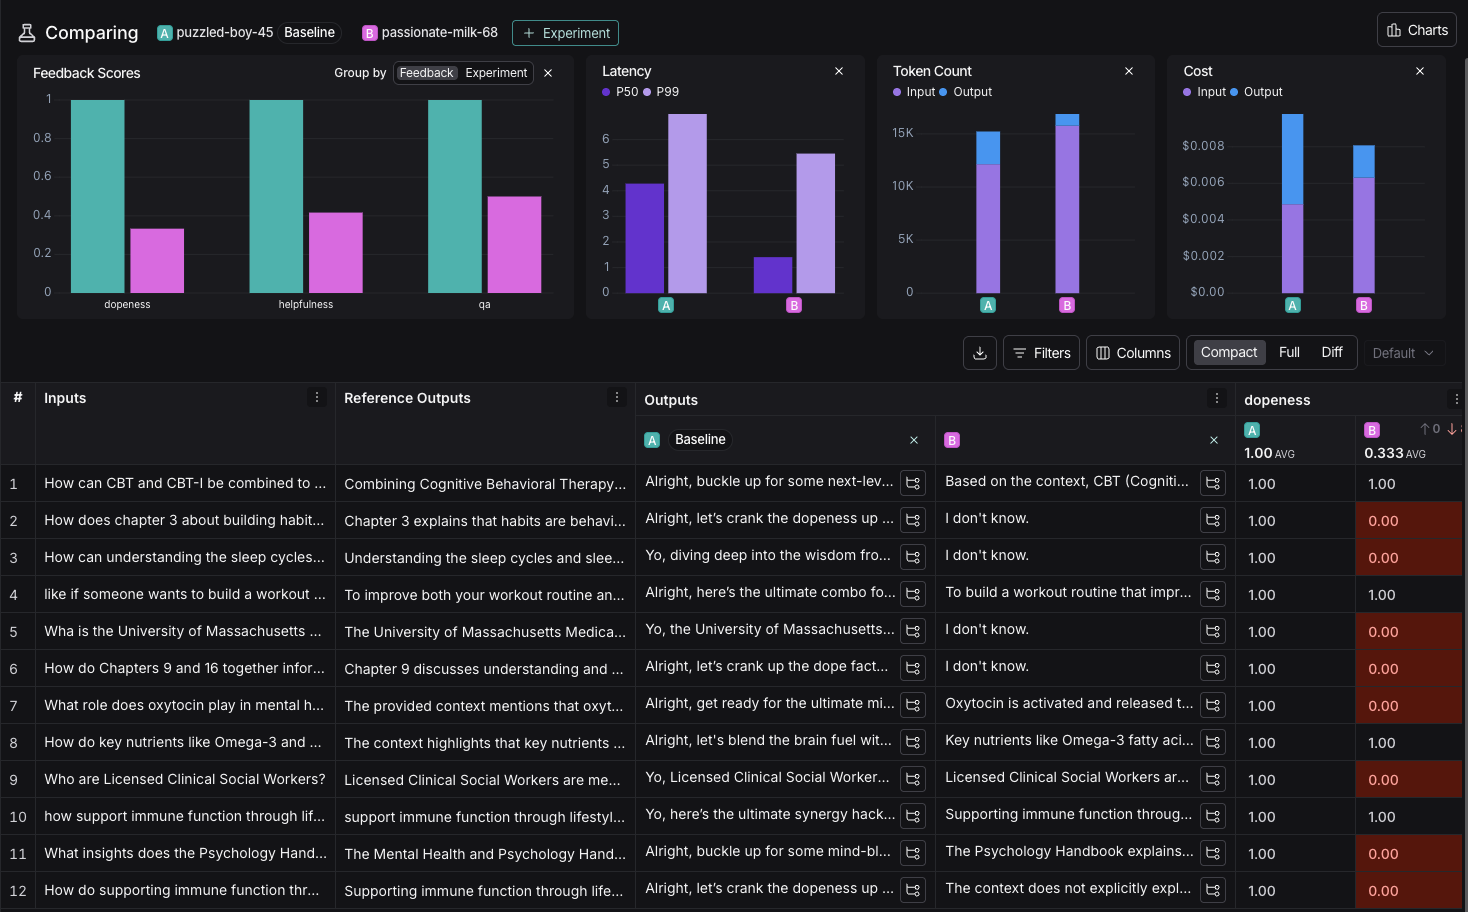

In [73]:
from IPython.display import Image

Image(filename='/Users/risheeksomu/AIE9/09_Synthetic_Data_Generation_and_LangSmith/Screenshot 2026-02-16 at 5.48.39 PM.png')

---
## Summary

In this session, we:

1. **Generated synthetic test data** using Ragas' knowledge graph-based approach
2. **Explored query synthesizers** for creating diverse question types
3. **Loaded synthetic data** into a LangSmith dataset for evaluation
4. **Built and evaluated a RAG chain** using LangSmith evaluators
5. **Iterated on the pipeline** by modifying chunk size, embedding model, and prompt — then measured the impact

### Key Takeaways:

- **Synthetic data generation** is critical for early iteration — it provides high-quality signal without manually creating test data
- **LangSmith evaluators** enable systematic comparison of pipeline versions
- **Small changes matter** — chunk size, embedding model, and prompt modifications can significantly affect evaluation scores